# 03. Causal Ablation at the Pre-NPI Position

- **Project:** Mechanistic analysis of NPI licensing in Gemma-2-2B
- **Stage:** Causal i.e. do the discovered features causally drive the model's NPI expectation?
- **Input:** npi_stimuli.csv + feature indices from notebook 03
- **Outputs:** 03_ablation_full.csv, 03_ablation.png
- **Runtime:** ~25 min

**Before running:** fill ABLATION_TARGETS with the 65k feature indices from notebook 02.

In [1]:
!pip install sae_lens transformers accelerate pandas matplotlib seaborn scipy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.2/312.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 101.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.4/298.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 21.3 MB/s eta 0:00:00


In [2]:
from kaggle_secrets import UserSecretsClient
import os
os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
from huggingface_hub import login
login(os.environ["HF_TOKEN"])
print("Authenticated.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated.


In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import gc, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_lens import SAE
import warnings
warnings.filterwarnings('ignore')
gc.collect(); torch.cuda.empty_cache()
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda:0


In [4]:
import glob, pandas as pd
csv_path = glob.glob("/kaggle/input/**/npi_stimuli.csv", recursive=True)[0]
stim_df = pd.read_csv(csv_path)
stimuli = list(stim_df[["item","condition","sentence","npi"]].itertuples(index=False, name=None))
item_info = stim_df.drop_duplicates("item").set_index("item")[["environment","design"]].to_dict("index")
triplet_items = set(stim_df[stim_df.design == "triplet"].item.unique())
print(f"Loaded {len(stimuli)} sentences, {stim_df.item.nunique()} items from {csv_path}")

ABLATION_TARGETS = {
    "L22_F6415_general":   [(22, 6415)],    # strongest general licenser
    "L20_F31666_general":  [(20, 31666)],   # 2nd general licenser
    "L14_F51903_negspec":  [(14, 51903)],   # negation-specific (poor generalizer) i.e. dissociation
    "CONTROL_L22_F22498":  [(22, 22498)],   # fires in A but not licensing-selective i.e. negative control
    "COMBINED":            [(22, 6415), (20, 31666), (18, 34114)],  # top 3 generalizers
}

assert not any(f == 99999 for t in ABLATION_TARGETS.values() for _, f in t), \
    "You must replace the placeholder 99999 feature indices with 02_discovery_prenpi results!"

unique_layers = sorted({l for t in ABLATION_TARGETS.values() for l, _ in t})
print(f"{len(stimuli)} stimuli, {len(ABLATION_TARGETS)} ablations, layers {unique_layers}")

Loaded 215 sentences, 80 items from /kaggle/input/datasets/iamahmadyasin/npi-stimuli/npi_stimuli.csv
215 stimuli, 5 ablations, layers [14, 18, 20, 22]


In [5]:
MODEL_NAME = "google/gemma-2-2b"
print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float16,
    device_map={"": "cuda:0"}, low_cpu_mem_usage=True)
model.eval()

saes = {}
for l in unique_layers:
    print(f"Loading SAE layer {l}...")
    sae, _, _ = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{l}/width_65k/canonical", device=device)
    sae.eval()
    saes[l] = sae
print(f"GPU: {torch.cuda.memory_allocated()/1e9:.2f} GB")

print(f"GPU after loading model + {len(saes)} SAEs: {torch.cuda.memory_allocated()/1e9:.2f} GB")
total = torch.cuda.get_device_properties(0).total_memory / 1e9
used = torch.cuda.memory_allocated() / 1e9
print(f"GPU total: {total:.1f} GB, used: {used:.1f} GB, free: {total-used:.1f} GB")
if total - used < 2.0:
    print("Low free memory. If the forward pass OOMs, run single-layer targets "
          "separately (comment out COMBINED, run one target at a time).")

Loading model...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Loading SAE layer 20...


layer_20/width_65k/average_l0_114/params(…):   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading SAE layer 22...


layer_22/width_65k/average_l0_116/params(…):   0%|          | 0.00/1.21G [00:00<?, ?B/s]

GPU: 10.06 GB
GPU after loading model + 4 SAEs: 10.06 GB
GPU total: 15.6 GB, used: 10.1 GB, free: 5.6 GB


In [6]:
def find_any_position(sentence, tokenizer):
    inputs = tokenizer(sentence, return_tensors="pt")
    ids = inputs["input_ids"][0]
    for i in range(len(ids)):
        if tokenizer.decode([ids[i].item()]).strip().lower() == "any":
            return i, inputs
    return None, inputs


def make_prehook(sae, features_to_ablate, target_pos, ablate=True):
    def prehook(module, args, kwargs):
        hidden = args[0]
        act = hidden[0, target_pos].detach().to(torch.float16)
        feats = sae.encode(act.unsqueeze(0))
        if ablate:
            for fi in features_to_ablate:
                feats[0, fi] = 0.0
        recon = sae.decode(feats).squeeze(0).to(hidden.dtype)
        new_hidden = hidden.clone()
        new_hidden[0, target_pos] = recon
        return ((new_hidden,) + args[1:], kwargs)
    return prehook


def get_p_any(sentence, ablation_config, recon_only_layers=None):
    any_pos, inputs = find_any_position(sentence, tokenizer)
    if any_pos is None:
        return None
    pre_pos = any_pos - 1
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    by_layer = {}
    for layer, feat in ablation_config:
        by_layer.setdefault(layer, []).append(feat)

    handles = []
    for layer, feats in by_layer.items():
        h = model.model.layers[layer + 1].register_forward_pre_hook(
            make_prehook(saes[layer], feats, pre_pos, ablate=True), with_kwargs=True)
        handles.append(h)
    if recon_only_layers:
        for layer in recon_only_layers:
            if layer in by_layer:
                continue
            h = model.model.layers[layer + 1].register_forward_pre_hook(
                make_prehook(saes[layer], [], pre_pos, ablate=False), with_kwargs=True)
            handles.append(h)
    try:
        with torch.no_grad():
            logits = model(**inputs, use_cache=False).logits[0]
        ids = inputs["input_ids"][0]
        lp = torch.log_softmax(logits[pre_pos].float(), dim=-1)
        return lp[ids[any_pos].item()].item()
    finally:
        for h in handles:
            h.remove()


first_target = list(ABLATION_TARGETS.values())[0]
ts = stimuli[0][2]
base = get_p_any(ts, [])
recon = get_p_any(ts, [], recon_only_layers=[first_target[0][0]])
abl = get_p_any(ts, first_target)

print(f"  Baseline:                    {base:.5f}")
print(f"  Recon-only (no ablation):    {recon:.5f}  (diff {base-recon:+.5f})")
print(f"  First target ablated:        {abl:.5f}  (diff from recon {recon-abl:+.5f})")

assert abs(base - recon) > 1e-5, \
    "Recon-only has zero effect i.e. the intervention is not upstream of the measurement. Stop."
print("Intervention is causally upstream of the measurement i.e. recon artifact is nonzero. Proceed.")

  Baseline:                    -4.86486
  Recon-only (no ablation):    -4.70054  (diff -0.16432)
  First target ablated:        -6.28059  (diff from recon +1.58005)
Intervention is causally upstream of the measurement i.e. recon artifact is nonzero. Proceed.


In [7]:
print("Running full ablation experiment at pre-NPI position...")
results = []
for i, (item, condition, sentence, _) in enumerate(stimuli):
    row = {"item": item, "condition": condition, "sentence": sentence}
    row["baseline"] = get_p_any(sentence, [])
    for l in unique_layers:
        row[f"recon_L{l}"] = get_p_any(sentence, [], recon_only_layers=[l])
    row["recon_all"] = get_p_any(sentence, [], recon_only_layers=list(unique_layers))
    for name, targets in ABLATION_TARGETS.items():
        row[f"ablate_{name}"] = get_p_any(sentence, targets)
    results.append(row)
    if (i + 1) % 15 == 0:
        print(f"  {i + 1}/{len(stimuli)}")

df = pd.DataFrame(results)
print(f"Done. {len(df)} sentences.")

Running full ablation experiment at pre-NPI position...
  15/215
  30/215
  45/215
  60/215
  75/215
  90/215
  105/215
  120/215
  135/215
  150/215
  165/215
  180/215
  195/215
  210/215
Done. 215 sentences.


In [8]:

print("SAE RECONSTRUCTION ARTIFACT")
for l in unique_layers:
    print(f"  Layer {l}: mean |baseline-recon| = {(df['baseline'] - df[f'recon_L{l}']).abs().mean():.4f}")
print(f"  All:     mean |baseline-recon| = {(df['baseline'] - df['recon_all']).abs().mean():.4f}")
print("\nNOTE: effects below use recon as baseline (recon - ablate), so the SAE")
print("reconstruction artifact CANCELS. Significance is judged vs the CONTROL")
print("feature and vs zero (selectivity t-test), NOT vs the number above.")

for name, targets in ABLATION_TARGETS.items():
    lyrs = sorted({l for l, _ in targets})
    bcol = f"recon_L{lyrs[0]}" if len(lyrs) == 1 else "recon_all"
    df[f"effect_{name}"] = df[bcol] - df[f"ablate_{name}"]

print("MEAN ABLATION EFFECT BY CONDITION (positive = reduced P('any'))")
ecols = [f"effect_{n}" for n in ABLATION_TARGETS.keys()]
print(df.groupby("condition")[ecols].mean().round(4).T)

print("SELECTIVITY (paired t-test: effect in A vs C)")
for name in ABLATION_TARGETS.keys():
    a = df[df["condition"] == "A"].set_index("item")[f"effect_{name}"]
    c = df[df["condition"] == "C"].set_index("item")[f"effect_{name}"]
    common = a.index.intersection(c.index)
    diffs = a.loc[common] - c.loc[common]
    t, p = stats.ttest_rel(a.loc[common], c.loc[common])
    d = diffs.mean() / diffs.std() if diffs.std() > 0 else 0
    print(f"\n{name}: A={a.loc[common].mean():.4f} C={c.loc[common].mean():.4f} "
          f"A-C={diffs.mean():.4f}  t={t:.3f} p={p:.6f} d={d:.3f}")

print("EFFECT vs CONTROL (is the scope feature's A-effect bigger than the control's?)")
control_name = next(n for n in ABLATION_TARGETS if n.startswith("CONTROL"))
ctrl_a = df[df["condition"]=="A"].set_index("item")[f"effect_{control_name}"]

for name in ABLATION_TARGETS.keys():
    if name.startswith("CONTROL"):
        continue
    a = df[df["condition"]=="A"].set_index("item")[f"effect_{name}"]
    common = a.index.intersection(ctrl_a.index)
    diff = a.loc[common] - ctrl_a.loc[common]
    t, p = stats.ttest_rel(a.loc[common], ctrl_a.loc[common])
    print(f"  {name:24s} A-effect={a.loc[common].mean():+.4f}  "
          f"vs control={ctrl_a.loc[common].mean():+.4f}  "
          f"Δ={diff.mean():+.4f}  t={t:.2f} p={p:.5f}")

df["environment"] = df["item"].map(lambda x: item_info[x]["environment"])
print("PER-ENVIRONMENT ABLATION EFFECT IN CONDITION A")
for name in ABLATION_TARGETS.keys():
    print(f"\n{name}:")
    for env in ["sentential_negation","no_subject","few_subject","question","without"]:
        sub = df[(df.environment == env) & (df.condition == "A")]
        if len(sub):
            print(f"  {env:20s} mean effect = {sub[f'effect_{name}'].mean():+.4f}  (n={len(sub)})")

SAE RECONSTRUCTION ARTIFACT
  Layer 14: mean |baseline-recon| = 0.4841
  Layer 18: mean |baseline-recon| = 0.6857
  Layer 20: mean |baseline-recon| = 0.6849
  Layer 22: mean |baseline-recon| = 0.7175
  All:     mean |baseline-recon| = 1.3705

NOTE: effects below use recon as baseline (recon - ablate), so the SAE
reconstruction artifact CANCELS. Significance is judged vs the CONTROL
feature and vs zero (selectivity t-test), NOT vs the number above.
MEAN ABLATION EFFECT BY CONDITION (positive = reduced P('any'))
condition                       A       B       C
effect_L22_F6415_general   1.4361  0.3970  0.0395
effect_L20_F31666_general  2.6938  0.4358  0.1137
effect_L14_F51903_negspec  0.1204  0.0000  0.0332
effect_CONTROL_L22_F22498  0.0261  0.0000  0.0000
effect_COMBINED            3.1451  0.4387  0.1827
SELECTIVITY (paired t-test: effect in A vs C)

L22_F6415_general: A=1.4361 C=0.0395 A-C=1.3967  t=12.886 p=0.000000 d=1.441

L20_F31666_general: A=2.6938 C=0.1137 A-C=2.5801  t=17.480 

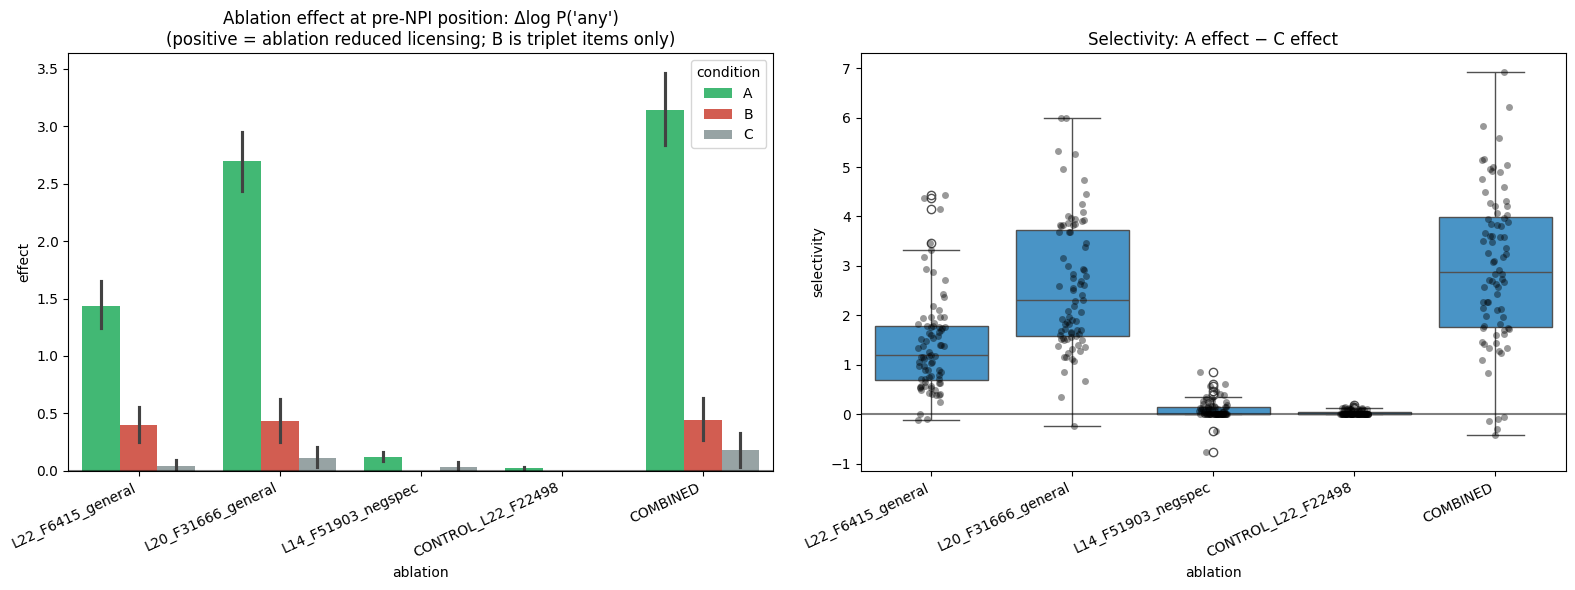

Saved 03_ablation.png and 03_ablation_full.csv


In [9]:
rows = []
for _, r in df.iterrows():
    for name in ABLATION_TARGETS.keys():
        if r["condition"] == "B" and r["item"] not in triplet_items:
            continue
        rows.append({"item": r["item"], "condition": r["condition"],
                     "ablation": name, "effect": r[f"effect_{name}"]})
pdf = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=pdf, x="ablation", y="effect", hue="condition",
            hue_order=["A","B","C"], ax=ax[0],
            palette={"A":"#2ecc71","B":"#e74c3c","C":"#95a5a6"})
ax[0].axhline(0, color='black', alpha=0.5)
ax[0].set_title("Ablation effect at pre-NPI position: Δlog P('any')\n"
                "(positive = ablation reduced licensing; B is triplet items only)")
ax[0].tick_params(axis='x', rotation=25)
for lab in ax[0].get_xticklabels(): lab.set_ha('right')

sel = pdf.pivot_table(index="item", columns=["ablation","condition"], values="effect")
sd = []
for name in ABLATION_TARGETS.keys():
    if (name,"A") in sel.columns and (name,"C") in sel.columns:
        for it, v in (sel[(name,"A")] - sel[(name,"C")]).items():
            sd.append({"ablation": name, "selectivity": v})
sdf = pd.DataFrame(sd)
sns.boxplot(data=sdf, x="ablation", y="selectivity", ax=ax[1], color="#3498db")
sns.stripplot(data=sdf, x="ablation", y="selectivity", ax=ax[1], color="black", alpha=0.4)
ax[1].axhline(0, color='black', alpha=0.5)
ax[1].set_title("Selectivity: A effect − C effect")
ax[1].tick_params(axis='x', rotation=25)
for lab in ax[1].get_xticklabels(): lab.set_ha('right')

plt.tight_layout()
plt.savefig("03_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
df.to_csv("03_ablation_full.csv", index=False)
print("Saved 03_ablation.png and 03_ablation_full.csv")


In [10]:
# free SAEs not needed for the reverse test
for l in [20, 22]:
    if l in saes:
        del saes[l]
gc.collect(); torch.cuda.empty_cache()
print(f"GPU after freeing 20,22: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU after freeing 20,22: 8.86 GB


In [11]:
# REVERSE ABLATION: do "unlicensed" features suppress P("any") in C?

INVERSE_TARGETS = {
    "L12_F56118_unlic": [(12, 56118)],
    "L14_F33172_unlic": [(14, 33172)],
    "L16_F44439_unlic": [(16, 44439)],
    "L18_F30313_unlic": [(18, 30313)],
    "INV_COMBINED":     [(12, 56118), (14, 33172), (16, 44439), (18, 30313)],
}

needed = sorted({l for t in INVERSE_TARGETS.values() for l, _ in t})
for l in needed:
    if l not in saes:
        print(f"Loading SAE layer {l} (new for reverse test)...")
        sae, _, _ = SAE.from_pretrained(
            release="gemma-scope-2b-pt-res-canonical",
            sae_id=f"layer_{l}/width_65k/canonical", device=device)
        sae.eval()
        saes[l] = sae
print(f"GPU after loading: {torch.cuda.memory_allocated()/1e9:.2f} GB")

inv_rows = []
for i, (item, condition, sentence, _) in enumerate(stimuli):
    row = {"item": item, "condition": condition,
           "environment": item_info[item]["environment"]}
    for l in needed:
        row[f"recon_L{l}"] = get_p_any(sentence, [], recon_only_layers=[l])
    row["recon_all_inv"] = get_p_any(sentence, [], recon_only_layers=needed)
    for name, targets in INVERSE_TARGETS.items():
        row[f"ablate_{name}"] = get_p_any(sentence, targets)
    inv_rows.append(row)
    if (i + 1) % 30 == 0:
        print(f"  {i+1}/{len(stimuli)}")

idf = pd.DataFrame(inv_rows)

# effect = recon - ablate. NEGATIVE effect = ablation INCREASED P("any").
for name, targets in INVERSE_TARGETS.items():
    lyrs = sorted({l for l, _ in targets})
    bcol = f"recon_L{lyrs[0]}" if len(lyrs) == 1 else "recon_all_inv"
    idf[f"effect_{name}"] = idf[bcol] - idf[f"ablate_{name}"]

print("REVERSE ABLATION: mean effect by condition")
print("(NEGATIVE in C = ablating the 'unlicensed' feature RAISED P('any'),")
print(" i.e. the feature was causally suppressing the unlicensed NPI)")
ecols = [f"effect_{n}" for n in INVERSE_TARGETS.keys()]
print(idf.groupby("condition")[ecols].mean().round(4).T)

print("Is the effect in condition C significantly BELOW zero? (one-sample t-test vs 0)")
for name in INVERSE_TARGETS.keys():
    c_eff = idf[idf["condition"]=="C"][f"effect_{name}"]
    t, p = stats.ttest_1samp(c_eff, 0.0)
    print(f"  {name:22s} mean C effect={c_eff.mean():+.4f}  t={t:.2f}  p={p:.5f}")

idf.to_csv("/kaggle/working/04_reverse_ablation.csv", index=False)
print("\nSaved 04_reverse_ablation.csv")

Loading SAE layer 12 (new for reverse test)...


layer_12/width_65k/average_l0_72/params.(…):   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading SAE layer 16 (new for reverse test)...


layer_16/width_65k/average_l0_128/params(…):   0%|          | 0.00/1.21G [00:00<?, ?B/s]

GPU after loading: 10.07 GB
  30/215
  60/215
  90/215
  120/215
  150/215
  180/215
  210/215
REVERSE ABLATION: mean effect by condition
(NEGATIVE in C = ablating the 'unlicensed' feature RAISED P('any'),
 i.e. the feature was causally suppressing the unlicensed NPI)
condition                     A    B       C
effect_L12_F56118_unlic  0.0000  0.0  0.2527
effect_L14_F33172_unlic  0.0000  0.0  0.1623
effect_L16_F44439_unlic  0.0001  0.0  0.1066
effect_L18_F30313_unlic  0.0000  0.0  0.0196
effect_INV_COMBINED      0.0000  0.0  0.0164
Is the effect in condition C significantly BELOW zero? (one-sample t-test vs 0)
  L12_F56118_unlic       mean C effect=+0.2527  t=3.79  p=0.00030
  L14_F33172_unlic       mean C effect=+0.1623  t=3.71  p=0.00038
  L16_F44439_unlic       mean C effect=+0.1066  t=3.88  p=0.00021
  L18_F30313_unlic       mean C effect=+0.0196  t=1.78  p=0.07935
  INV_COMBINED           mean C effect=+0.0164  t=0.46  p=0.64430

Saved 04_reverse_ablation.csv
